In [ ]:
# Install necessary libraries
!pip install sentence-transformers hdbscan umap-learn
!pip install text2num

In [ ]:
import os

# The zip file name is provided by the user.
zip_file = "OneDrive_1_6-18-2026.zip"

# Check if the zip file exists before attempting to unzip.
if os.path.exists(zip_file):
    # Unzip the file using the shell command. The -o option overwrites files without prompting.
    !unzip -o {zip_file}
    print(f"'{zip_file}' has been unzipped.")
else:
    print(f"Error: The file '{zip_file}' was not found.")

Archive:  OneDrive_1_6-18-2026.zip
 extracting: akjv.json               
 extracting: bsb.json                
 extracting: kjv.json                
 extracting: web.json                
'OneDrive_1_6-18-2026.zip' has been unzipped.


In [ ]:
import re
import pandas as pd
import json

json_files = ['akjv.json', 'bsb.json', 'kjv.json', 'web.json'] # Modified to process all JSON files
all_aggregated_verses = []

for file_name in json_files:
    try:
        with open(file_name, 'r') as f:
            data = json.load(f)

            source_name = file_name.replace('.json', '')

            for verse_key, verse_text in data.items():
                # Updated regex to correctly parse book names that start with a number (e.g., '1 Samuel')
                # It now allows an optional digit at the beginning of the book name.
                match = re.match(r'(\d?\s*[a-zA-Z\s]+)\s(\d+):(\d+)', verse_key)
                if match:
                    book, chapter, verse_num = match.groups()
                    all_aggregated_verses.append({
                        'source': source_name,
                        'book': book.strip(),
                        'chapter': int(chapter),
                        'verse_number': int(verse_num),
                        'text': verse_text
                    })
                else:
                    print(f"Warning: Could not parse verse key '{verse_key}' from {file_name}")

    except FileNotFoundError:
        print(f"Error: File '{file_name}' not found.")
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{file_name}'.")

df_aggregated = pd.DataFrame(all_aggregated_verses)

# Removed the filter for 'Genesis' to include all books

display(df_aggregated.head())
df_aggregated.info()

,source,book,chapter,verse_number,text
0,akjv,Genesis,1,1,In the beginning God created the heaven and th...
1,akjv,Genesis,1,2,"And the earth was without form, and void; and ..."
2,akjv,Genesis,1,3,"And God said, Let there be light: and there wa..."
3,akjv,Genesis,1,4,"And God saw the light, that it was good: and G..."
4,akjv,Genesis,1,5,"And God called the light Day, and the darkness..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124388 entries, 0 to 124387
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   source        124388 non-null  object
 1   book          124388 non-null  object
 2   chapter       124388 non-null  int64 
 3   verse_number  124388 non-null  int64 
 4   text          124388 non-null  object
dtypes: int64(2), object(3)
memory usage: 4.7+ MB


In [ ]:
from text_to_num import alpha2digit

# Apply alpha2digit to the 'text' column of df_aggregated
df_aggregated['normalized_text'] = df_aggregated['text'].apply(lambda x: alpha2digit(x, "en"))

# Display the DataFrame with the new normalized_text column
display(df_aggregated.head())

,source,book,chapter,verse_number,text,normalized_text
0,akjv,Genesis,1,1,In the beginning God created the heaven and th...,In the beginning God created the heaven and th...
1,akjv,Genesis,1,2,"And the earth was without form, and void; and ...","And the earth was without form, and void; and ..."
2,akjv,Genesis,1,3,"And God said, Let there be light: and there wa...","And God said, Let there be light: and there wa..."
3,akjv,Genesis,1,4,"And God saw the light, that it was good: and G...","And God saw the light, that it was good: and G..."
4,akjv,Genesis,1,5,"And God called the light Day, and the darkness...","And God called the light Day, and the darkness..."


In [ ]:
def encode_texts_with_voyage(texts):
    """
    Encodes a list of texts into vectors using 'voyageai/voyage-4-nano'.

    Args:
        texts (list): A list of strings to be encoded.

    Returns:
        numpy.ndarray: An array of embeddings for each text.
    """
    print("Loading SentenceTransformer model 'voyageai/voyage-4-nano'...")
    model = SentenceTransformer('voyageai/voyage-4-nano')

    print(f"Encoding {len(texts)} texts...")
    embeddings = model.encode(texts, show_progress_bar=True)

    return embeddings

In [ ]:
def cluster_embeddings_with_hdbscan(embeddings, min_cluster_size=5, min_samples=None, metric='euclidean'):
    """
    Clusters a list of embeddings using HDBSCAN.

    Args:
        embeddings (numpy.ndarray): An array of embeddings to be clustered.
        min_cluster_size (int): The minimum size of clusters passed to HDBSCAN.
        min_samples (int, optional): The number of samples in a neighborhood for a point to be considered a core point.
                                     Defaults to None, which means min_cluster_size will be used.
        metric (str): The distance metric to use for HDBSCAN. Defaults to 'euclidean'.

    Returns:
        numpy.ndarray: An array of cluster labels for each embedding. -1 indicates noise points.
    """
    print("Performing HDBSCAN clustering...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric
    )
    cluster_labels = clusterer.fit_predict(embeddings)

    return cluster_labels

# Example Usage (uncomment to test):
# if __name__ == '__main__':
#     sample_texts = [
#         "The quick brown fox jumps over the lazy dog.",
#         "A fast brown fox leaps over a sleeping canine.",
#         "Cats chase mice and play with yarn.",
#         "Dogs love to fetch and play in the park.",
#         "The red car is parked outside.",
#         "A crimson automobile is sitting on the street.",
#         "I like to eat apples.",
#         "He enjoys eating bananas."
#     ]

#     # 1. Encode texts
#     embeddings = encode_texts_with_voyage(sample_texts)

#     # 2. Cluster embeddings
#     labels = cluster_embeddings_with_hdbscan(embeddings)
#     print("\nCluster labels:", labels)

#     for i, (text, label) in enumerate(zip(sample_texts, labels)):
#         print(f"Text {i+1} (Cluster {label}): {text}")


In [ ]:
from sentence_transformers import SentenceTransformer
import hdbscan
from tqdm.auto import tqdm

tqdm.pandas() # Enable tqdm for pandas operations if needed, though encode already has progress bar.


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm.auto import tqdm
import torch
import umap

# Detect device (GPU if available, otherwise CPU)
if torch.cuda.is_available():
    device = 'cuda'
    print(f"PyTorch detected GPU: {torch.cuda.get_device_name(0)}")
else:
    device = 'cpu'
    print("PyTorch did not detect a GPU. Using CPU.")

# Load the SentenceTransformer model directly within this cell, explicitly moving it to the detected device
print(f"Loading SentenceTransformer model 'voyageai/voyage-4-nano' on {device}...")
model = SentenceTransformer('voyageai/voyage-4-nano', device=device)

# Prepare texts for encoding
texts_to_encode = df_aggregated['normalized_text'].tolist()

# Set a batch size for encoding to manage memory usage
batch_size = 32 # You can adjust this value based on available memory and performance
all_embeddings = []

print(f"Encoding {len(texts_to_encode)} texts in batches of {batch_size}...")
for i in tqdm(range(0, len(texts_to_encode), batch_size), desc="Encoding texts"):
    batch = texts_to_encode[i:i + batch_size]
    batch_embeddings = model.encode(batch, show_progress_bar=False, convert_to_numpy=True)
    all_embeddings.extend(batch_embeddings.tolist())

df_aggregated['embedding'] = all_embeddings

# Convert embeddings to a NumPy array for UMAP and HDBSCAN
embeddings_array = np.array(all_embeddings)

# Perform UMAP dimensionality reduction to 128 dimensions
print('\nPerforming UMAP dimensionality reduction to 128 dimensions...')
reducer = umap.UMAP(n_components=128, random_state=42)
reduced_embeddings = reducer.fit_transform(embeddings_array)

# Perform clustering on the reduced embeddings
print('\nPerforming HDBSCAN clustering on reduced embeddings...')
df_aggregated['cluster_label'] = cluster_embeddings_with_hdbscan(reduced_embeddings)

# Display the DataFrame with the new columns
display(df_aggregated.head())
df_aggregated.info()

PyTorch detected GPU: Tesla T4
Loading SentenceTransformer model 'voyageai/voyage-4-nano' on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/9.82k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

...


Performing UMAP dimensionality reduction to 128 dimensions...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Performing HDBSCAN clustering on reduced embeddings...
Performing HDBSCAN clustering...


,source,book,chapter,verse_number,text,normalized_text,embedding,cluster_label
0,akjv,Genesis,1,1,In the beginning God created the heaven and th...,In the beginning God created the heaven and th...,"[0.047119140625, 0.05517578125, -0.00189208984...",3884
1,akjv,Genesis,1,2,"And the earth was without form, and void; and ...","And the earth was without form, and void; and ...","[0.031494140625, -0.00457763671875, 0.00607299...",2531
2,akjv,Genesis,1,3,"And God said, Let there be light: and there wa...","And God said, Let there be light: and there wa...","[0.01318359375, -0.048583984375, 0.00433349609...",-1
3,akjv,Genesis,1,4,"And God saw the light, that it was good: and G...","And God saw the light, that it was good: and G...","[0.042236328125, -0.01336669921875, 0.00144958...",-1
4,akjv,Genesis,1,5,"And God called the light Day, and the darkness...","And God called the light Day, and the darkness...","[0.041015625, -0.031982421875, 1.7657876014709...",3466


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124388 entries, 0 to 124387
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   source           124388 non-null  object
 1   book             124388 non-null  object
 2   chapter          124388 non-null  int64 
 3   verse_number     124388 non-null  int64 
 4   text             124388 non-null  object
 5   normalized_text  124388 non-null  object
 6   embedding        124388 non-null  object
 7   cluster_label    124388 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 7.6+ MB


In [ ]:
csv_file_name = 'df_aggregated_with_embeddings_and_clusters.csv'
df_aggregated.to_csv(csv_file_name, index=False, encoding='utf-8-sig')
print(f"DataFrame saved to '{csv_file_name}' successfully.")

DataFrame saved to 'df_aggregated_with_embeddings_and_clusters.csv' successfully.


In [23]:
from google.colab import files

files.download('df_aggregated_with_embeddings_and_clusters.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cluster Statistics

In [ ]:
cluster_stats = df_aggregated.groupby('cluster_label').agg(
    num_verses=('verse_number', 'count'),
    avg_chapter=('chapter', 'mean'),
    avg_verse_number=('verse_number', 'mean')
).sort_values(by='num_verses', ascending=False)

display(cluster_stats)

### Cluster Analysis: Version and Chapter Distribution

In [ ]:
import pandas as pd

# Calculate the percentage of each source (version) within each cluster
cluster_version_percentages = df_aggregated.groupby('cluster_label')['source'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

print("Percentage of Sources (Versions) within Each Cluster:")
display(cluster_version_percentages)

# Calculate the percentage of each chapter within each cluster
cluster_chapter_percentages = df_aggregated.groupby('cluster_label')['chapter'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

print("\nPercentage of Chapters within Each Cluster:")
display(cluster_chapter_percentages)

Percentage of Sources (Versions) within Each Cluster:


,cluster_label,source,percentage
0,-1,bsb,25.515268
1,-1,kjv,24.988606
2,-1,web,24.975946
3,-1,akjv,24.520180
4,0,akjv,25.000000
...,...,...,...
25043,6351,kjv,16.000000
25044,6352,akjv,30.000000
25045,6352,bsb,30.000000
25046,6352,web,30.000000



Percentage of Chapters within Each Cluster:


,cluster_label,chapter,percentage
0,-1,2,5.378032
1,-1,1,5.215982
2,-1,4,4.474097
3,-1,3,4.408265
4,-1,5,3.770193
...,...,...,...
19551,6351,4,8.000000
19552,6351,10,4.000000
19553,6351,25,4.000000
19554,6352,18,70.000000


### Visualizing Version and Chapter Distribution in Clusters

/tmp/ipykernel_546/2509036941.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='percentage', data=cluster_data, palette='viridis', ax=ax)


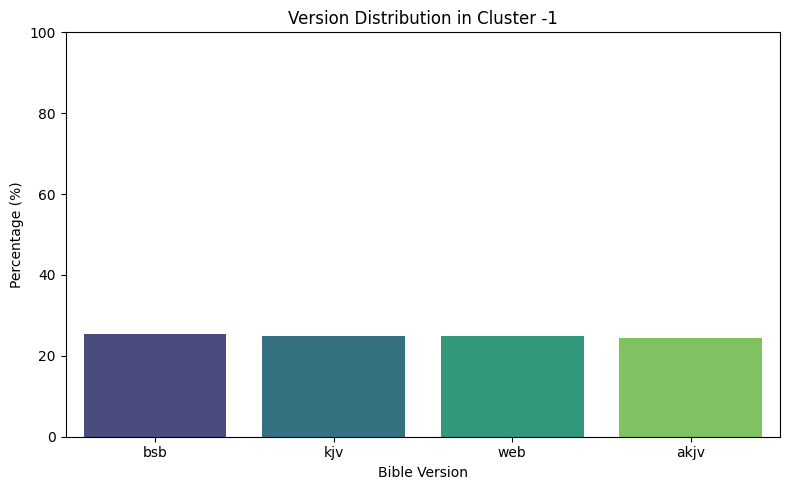

/tmp/ipykernel_546/2509036941.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='percentage', data=cluster_data, palette='viridis', ax=ax)


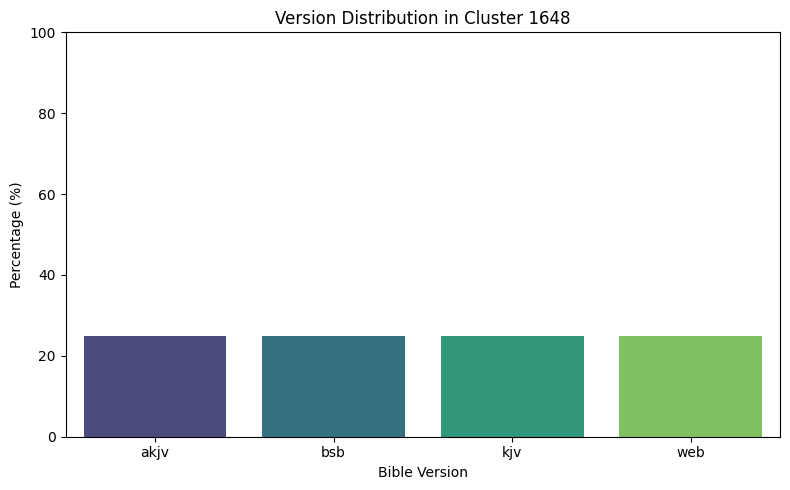

/tmp/ipykernel_546/2509036941.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='percentage', data=cluster_data, palette='viridis', ax=ax)


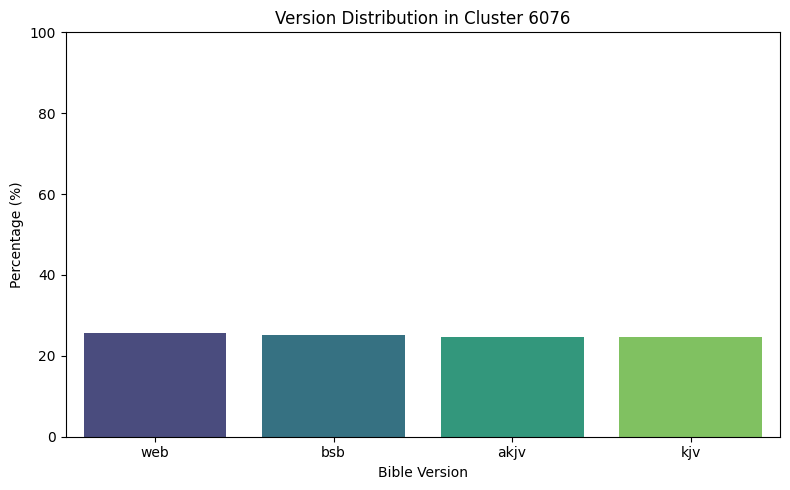

/tmp/ipykernel_546/2509036941.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='percentage', data=cluster_data, palette='viridis', ax=ax)


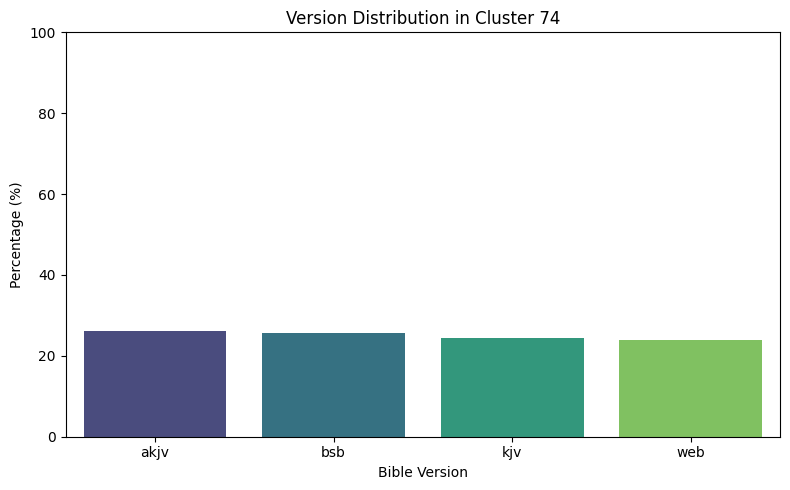

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top clusters based on the number of verses, including cluster -1 if it's large
# Filter out -1 if it's not considered a meaningful cluster for this analysis

# Let's consider the top 3 clusters by size, plus the noise cluster (-1) if it's present
# and has a significant number of verses. We will sort by size and pick the top ones.

# Get top 3 clusters by size from cluster_stats
top_clusters_by_size = cluster_stats.index.tolist()

# If -1 is the largest, we want to make sure it's included, and then the next few.
# Let's just pick the top 4 cluster labels, which should cover -1 and a few others.
selected_cluster_labels = top_clusters_by_size[:4]

# Plotting Version Percentages for Selected Clusters
for cluster_id in selected_cluster_labels:
    cluster_data = cluster_version_percentages[cluster_version_percentages['cluster_label'] == cluster_id]

    if not cluster_data.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.barplot(x='source', y='percentage', data=cluster_data, palette='viridis', ax=ax)
        ax.set_title(f'Version Distribution in Cluster {cluster_id}')
        ax.set_xlabel('Bible Version')
        ax.set_ylabel('Percentage (%)')
        plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100
        plt.tight_layout()
        plt.show()
    else:
        print(f"No version data for cluster {cluster_id}")

/tmp/ipykernel_546/2875252142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='chapter', y='percentage', data=top_chapters, palette='magma', ax=ax)


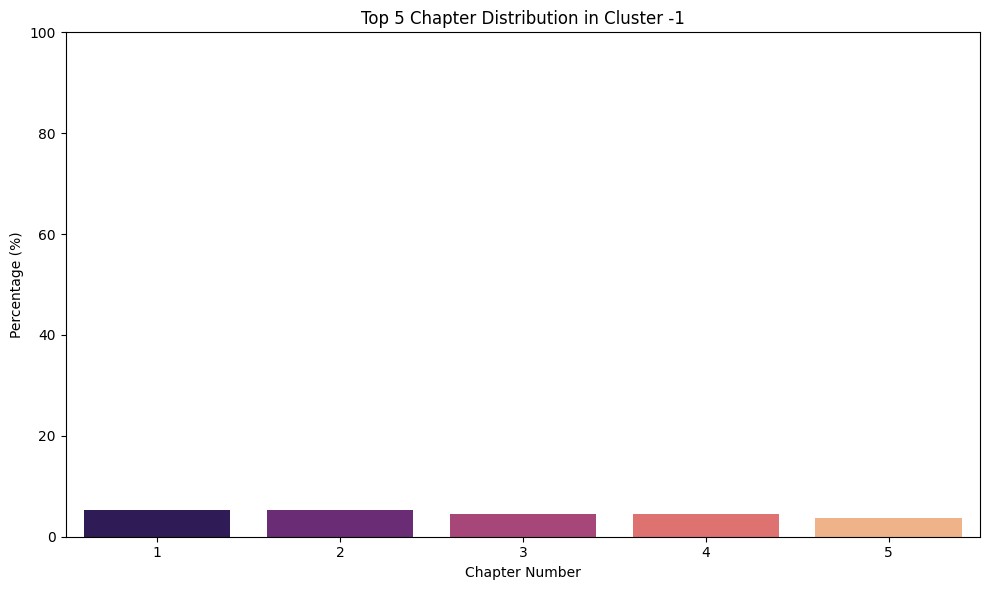

/tmp/ipykernel_546/2875252142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='chapter', y='percentage', data=top_chapters, palette='magma', ax=ax)


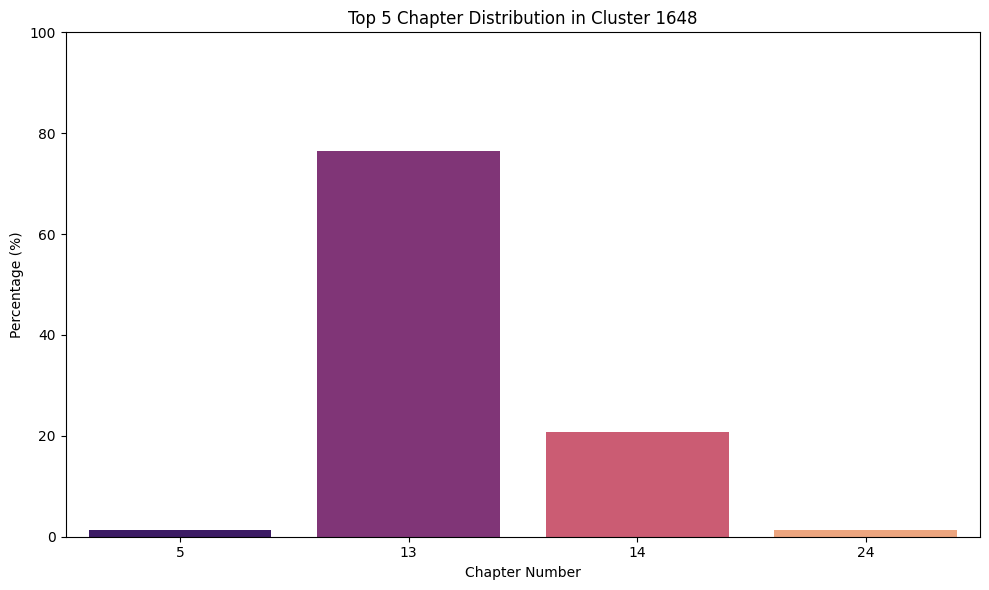

/tmp/ipykernel_546/2875252142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='chapter', y='percentage', data=top_chapters, palette='magma', ax=ax)


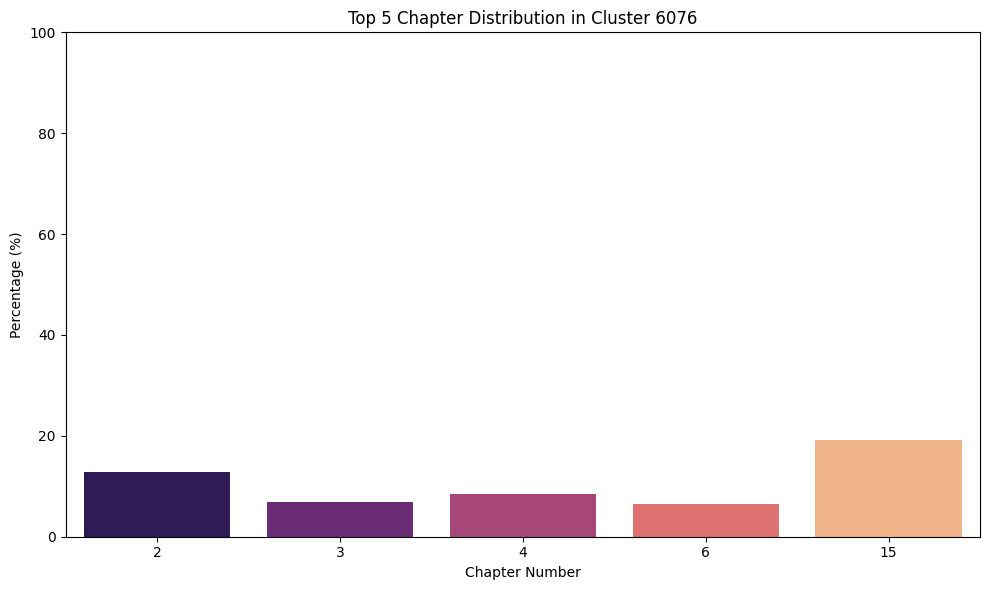

/tmp/ipykernel_546/2875252142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='chapter', y='percentage', data=top_chapters, palette='magma', ax=ax)


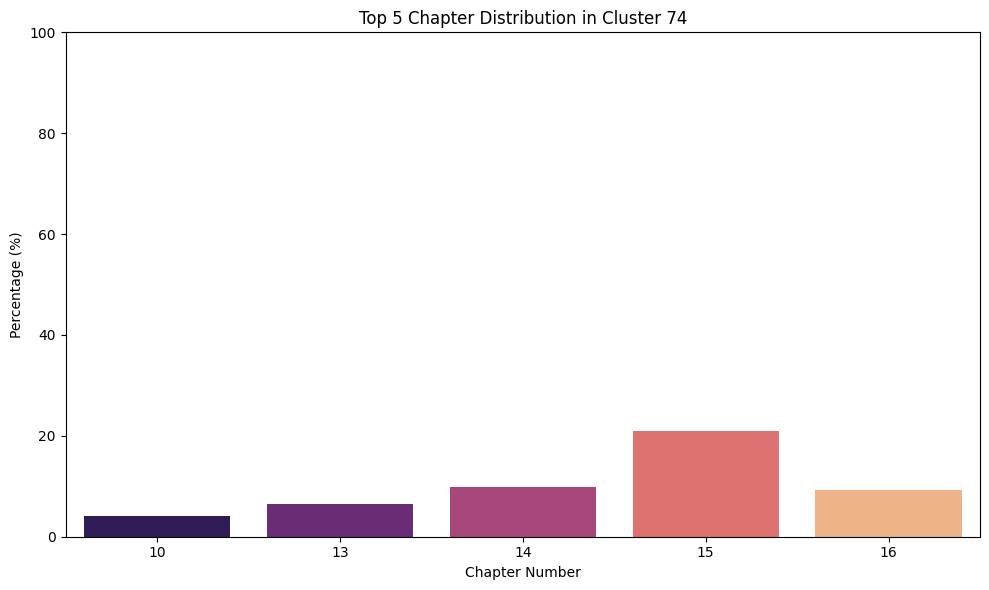

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Chapter Percentages for Selected Clusters (Top 5 chapters per cluster)
for cluster_id in selected_cluster_labels:
    cluster_data = cluster_chapter_percentages[cluster_chapter_percentages['cluster_label'] == cluster_id]

    if not cluster_data.empty:
        # Get top 5 chapters for the current cluster
        top_chapters = cluster_data.sort_values(by='percentage', ascending=False).head(5)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x='chapter', y='percentage', data=top_chapters, palette='magma', ax=ax)
        ax.set_title(f'Top 5 Chapter Distribution in Cluster {cluster_id}')
        ax.set_xlabel('Chapter Number')
        ax.set_ylabel('Percentage (%)')
        plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100
        plt.tight_layout()
        plt.show()
    else:
        print(f"No chapter data for cluster {cluster_id}")

### Visualize Clusters in 2D

### Chapter with Most Similar Sentences

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

chapter_similarities = {}

# Group the DataFrame by chapter
chapters_grouped = df_aggregated.groupby('chapter')

for chapter_num, group in tqdm(chapters_grouped, desc="Calculating chapter similarities"):
    # Ensure there's more than one verse to calculate similarity
    if len(group) > 1:
        # Extract embeddings for the current chapter
        chapter_embeddings = np.array(group['embedding'].tolist())

        # Calculate pairwise cosine similarity for all verses within the chapter
        similarity_matrix = cosine_similarity(chapter_embeddings)

        # Extract unique similarities (upper triangle excluding diagonal)
        # The diagonal elements are always 1 (similarity of a verse with itself)
        # The matrix is symmetric, so we only need one half.
        # We flatten the upper triangle and take the mean.
        upper_triangle_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
        unique_similarities = similarity_matrix[upper_triangle_indices]

        if unique_similarities.size > 0:
            chapter_similarities[chapter_num] = np.mean(unique_similarities)
        else:
            # Handle cases where after filtering, no unique pairs are left
            chapter_similarities[chapter_num] = 0.0
    else:
        # Chapters with only one verse have no pairwise similarity
        chapter_similarities[chapter_num] = 0.0

# Convert results to a DataFrame for easier analysis
similarity_df = pd.DataFrame(
    list(chapter_similarities.items()),
    columns=['chapter', 'average_pairwise_similarity']
)

# Sort by similarity to find the most similar chapter
most_similar_chapter = similarity_df.sort_values(by='average_pairwise_similarity', ascending=False)

display(most_similar_chapter.head())

Calculating chapter similarities:   0%|          | 0/150 [00:00<?, ?it/s]

,chapter,average_pairwise_similarity
116,117,0.788578
149,150,0.714299
133,134,0.698863
66,67,0.682595
135,136,0.672590


### Chapter Similarity by Bible Version

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

version_chapter_similarities = []

# Group the DataFrame by source (Bible version) and then by chapter
versions_grouped = df_aggregated.groupby('source')

for source_name, source_group in tqdm(versions_grouped, desc="Calculating similarities by version"):
    chapters_grouped_by_source = source_group.groupby('chapter')

    for chapter_num, group in tqdm(chapters_grouped_by_source, desc=f"Processing {source_name}", leave=False):
        if len(group) > 1:
            chapter_embeddings = np.array(group['embedding'].tolist())
            similarity_matrix = cosine_similarity(chapter_embeddings)

            upper_triangle_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
            unique_similarities = similarity_matrix[upper_triangle_indices]

            if unique_similarities.size > 0:
                version_chapter_similarities.append({
                    'source': source_name,
                    'chapter': chapter_num,
                    'average_pairwise_similarity': np.mean(unique_similarities)
                })
            else:
                version_chapter_similarities.append({
                    'source': source_name,
                    'chapter': chapter_num,
                    'average_pairwise_similarity': 0.0
                })
        else:
            version_chapter_similarities.append({
                'source': source_name,
                'chapter': chapter_num,
                'average_pairwise_similarity': 0.0
            })

# Convert results to a DataFrame
similarity_by_version_df = pd.DataFrame(version_chapter_similarities)

# Display the top chapters for each version
for source_name in similarity_by_version_df['source'].unique():
    print(f"\nTop chapters by similarity for version: {source_name.upper()}")
    display(similarity_by_version_df[similarity_by_version_df['source'] == source_name]
            .sort_values(by='average_pairwise_similarity', ascending=False).head())


Performing UMAP dimensionality reduction to 2 dimensions for visualization...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


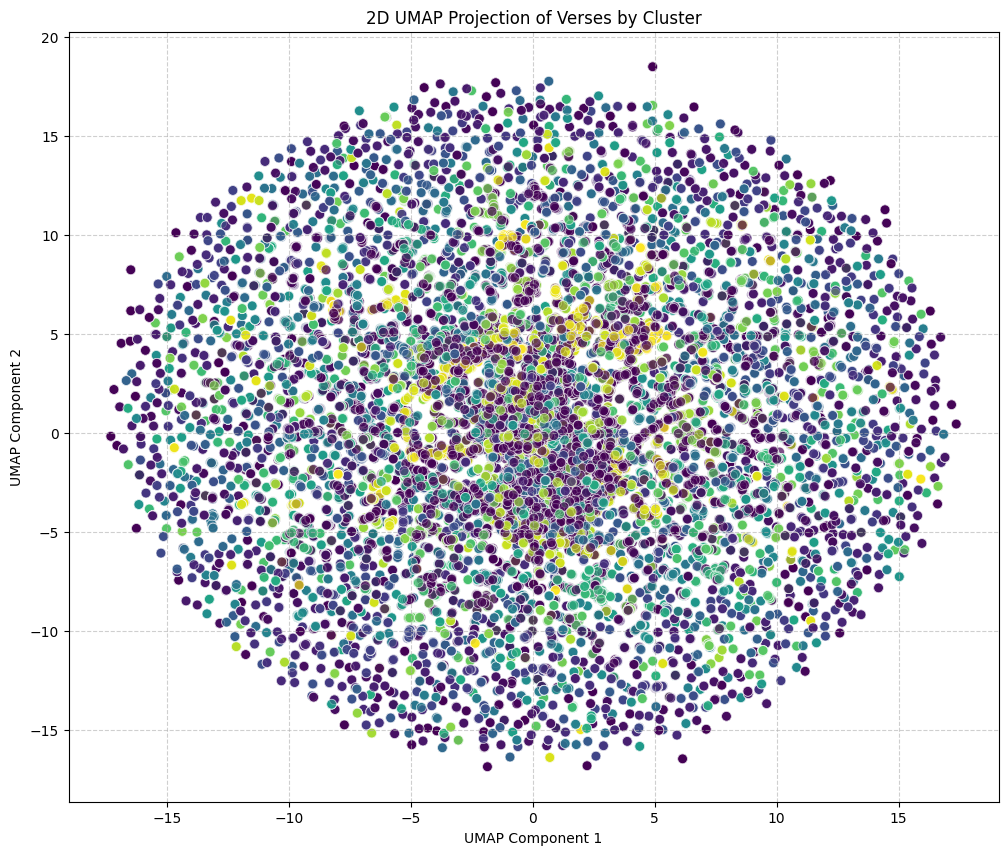

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perform UMAP dimensionality reduction to 2 dimensions for visualization
print('Performing UMAP dimensionality reduction to 2 dimensions for visualization...')
reducer_2d = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer_2d.fit_transform(reduced_embeddings)

# Add 2D embeddings to the DataFrame
df_aggregated['umap_x'] = embeddings_2d[:, 0]
df_aggregated['umap_y'] = embeddings_2d[:, 1]

# Visualize the clusters
fig = plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='umap_x',
    y='umap_y',
    hue='cluster_label',
    data=df_aggregated,
    palette='viridis',
    s=50, # size of points
    alpha=0.7,
    legend=False # Removed the long legend as requested
)
plt.title('2D UMAP Projection of Verses by Cluster')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
def upload_plt_to_gcs(num_fig, step, fig):
  """Placeholder function for uploading plot to GCS."""
  print(f"Uploading figure {num_fig} for step {step} to GCS (placeholder).")
  # In a real scenario, this would contain logic to save and upload the figure.

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ClusterAnalysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ClusterAnalysis"] {type:"string"}
# Assuming `fig` is the latest matplotlib figure generated
upload_plt_to_gcs(num_fig, step, fig)

Uploading figure 1 for step ClusterAnalysis to GCS (placeholder).
